In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import joblib

/var/folders/l1/zl_1nvhs4gz52x96jxvqm41m0000gp/T/ipykernel_81132/1797323550.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


**Load**

In [2]:
df = pd.read_csv('test_data.csv', delimiter=';')

Preview

In [22]:
df.head()

,TIPOLOGIA,VALOR,SUPERFICIE,DORMITORIOS,BANNOS,ANTIGUEDAD,ASCENSOR,EXTERIOR_INTERIOR,LONGITUD,LATITUD,CODPOS,CODMUN,PRECIO_M2
0,PLURIFAMILIAR,217704,111,3,2,1,si,INTERIOR,-4.51674,36.67090,29140,29067,1961.297297
1,PLURIFAMILIAR,161268,90,3,2,56,si,EXTERIOR,-4.35973,36.72343,29017,29067,1791.866667
2,PLURIFAMILIAR,250035,115,3,2,33,si,EXTERIOR,-4.41427,36.73288,29013,29067,2174.217391
3,PLURIFAMILIAR,335381,144,4,2,47,si,EXTERIOR,-4.43820,36.71650,29006,29067,2329.034722
4,PLURIFAMILIAR,353266,154,4,2,47,si,EXTERIOR,-4.43478,36.71886,29007,29067,2293.935065


Set Up

In [4]:

df['CODPOS'] = df['CODPOS'].astype(str)
df['CODMUN'] = df['CODMUN'].astype(str)
df['LONGITUD'] = df['LONGITUD'].str.replace(',', '.').astype(float)
df['LATITUD'] = df['LATITUD'].str.replace(',', '.').astype(float)
df['PRECIO_M2'] = df['VALOR'] / df['SUPERFICIE']
df['FECHA'] = pd.to_datetime(df['FECHA'])

quantitative = [f for f in df.columns if df.dtypes[f] != 'object']
qualitative = [f for f in df.columns if df.dtypes[f] == 'object']
qualitative_encoded = pd.get_dummies(df[qualitative])

qualitative_encoded['YEAR'] = df['FECHA'].dt.year
qualitative_encoded['MOTH'] = df['FECHA'].dt.month
qualitative_encoded['DAY'] = df['FECHA'].dt.day
qualitative_encoded['DAY_OF_WEEK'] = df['FECHA'].dt.dayofweek
qualitative_encoded['IS_WEEKEND'] = (df['FECHA'].dt.dayofweek >= 5).astype(int)
qualitative_encoded['QUARTER'] = df['FECHA'].dt.quarter
qualitative_encoded['IS_MONTH_END'] = df['FECHA'].dt.is_month_end.astype(int)

quantitative.remove('FECHA')
df.drop('FECHA', axis=1, inplace=True)

X = pd.concat([df[quantitative], qualitative_encoded], axis=1).drop(['VALOR', 'PRECIO_M2'], axis=1)
y = df['VALOR']

**Exploratory Data Analysis**

In [5]:
df.describe()

,VALOR,SUPERFICIE,DORMITORIOS,BANNOS,ANTIGUEDAD,LONGITUD,LATITUD,PRECIO_M2
count,3.618000e+03,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000,3618.000000
mean,2.367305e+05,106.369818,2.835544,1.707297,31.229961,-4.444500,36.718330,2209.253434
std,1.415540e+05,52.539410,0.868957,0.677255,23.874642,0.030973,0.016236,718.024905
min,1.700700e+04,29.000000,1.000000,1.000000,0.000000,-4.577130,36.646390,327.057692
25%,1.482312e+05,83.000000,2.000000,1.000000,12.000000,-4.464190,36.709590,1714.577724
50%,2.174820e+05,97.000000,3.000000,2.000000,29.000000,-4.441990,36.720890,2199.175376
75%,2.711520e+05,114.000000,3.000000,2.000000,49.000000,-4.427750,36.726393,2555.457688
max,1.728004e+06,1186.000000,13.000000,8.000000,212.000000,-4.304140,36.832630,5640.473684


In [6]:
df.dtypes

TIPOLOGIA             object
VALOR                  int64
SUPERFICIE             int64
DORMITORIOS            int64
BANNOS                 int64
ANTIGUEDAD             int64
ASCENSOR              object
EXTERIOR_INTERIOR     object
LONGITUD             float64
LATITUD              float64
CODPOS                object
CODMUN                object
PRECIO_M2            float64
dtype: object

In [7]:
quantitative

['VALOR',
 'SUPERFICIE',
 'DORMITORIOS',
 'BANNOS',
 'ANTIGUEDAD',
 'LONGITUD',
 'LATITUD',
 'PRECIO_M2']

In [8]:
qualitative

['TIPOLOGIA', 'ASCENSOR', 'EXTERIOR_INTERIOR', 'CODPOS', 'CODMUN']

In [9]:
df['PRECIO_M2'] = pd.to_numeric(df['PRECIO_M2'], errors='coerce')
top_postal_codes = df.groupby('CODPOS')['PRECIO_M2'].mean().sort_values(ascending=False).head(10)
top_postal_codes

CODPOS
29015    4340.079826
29016    3534.768828
29001    3475.925297
29005    3270.330230
29008    3101.367628
29012    2465.748854
29018    2438.465665
29010    2362.559618
29017    2316.488622
29002    2299.759581
Name: PRECIO_M2, dtype: float64

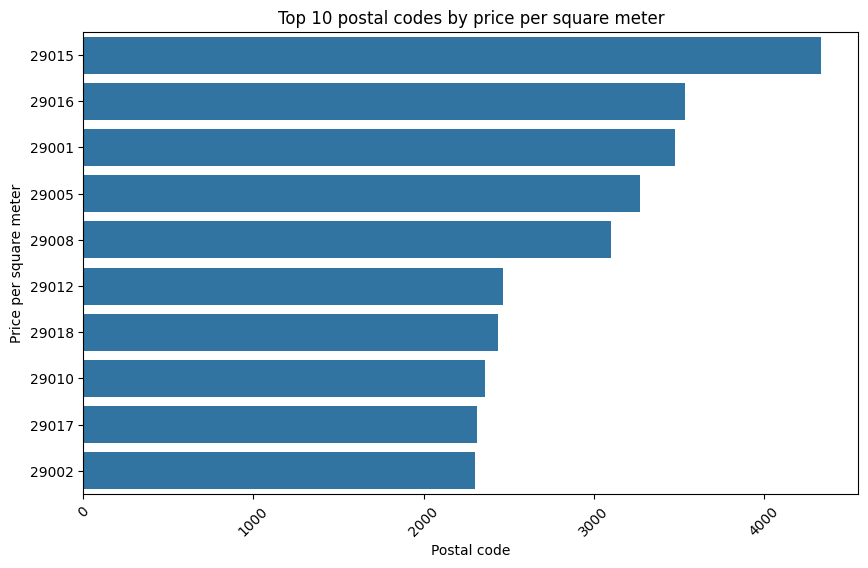

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(y=top_postal_codes.index, x=top_postal_codes.values)
plt.title('Top 10 postal codes by price per square meter')
plt.xlabel('Postal code')
plt.ylabel('Price per square meter')
plt.xticks(rotation=45)
plt.show()

/var/folders/l1/zl_1nvhs4gz52x96jxvqm41m0000gp/T/ipykernel_81132/1427098119.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_postal_codes['CODPOS'] = pd.Categorical(df_top_postal_codes['CODPOS'], categories=top_postal_codes, ordered=True)
/var/folders/l1/zl_1nvhs4gz52x96jxvqm41m0000gp/T/ipykernel_81132/1427098119.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_postal_codes.sort_values('CODPOS', inplace=True)


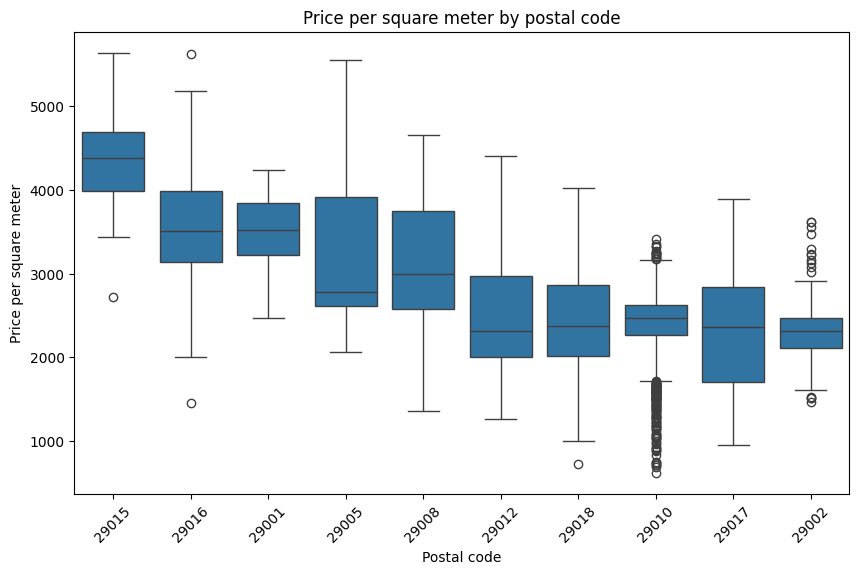

In [11]:
# Plot box plots for the top 10 postal codes in the same order as the bar plot
top_postal_codes = list(top_postal_codes.index)
df_top_postal_codes = df[df['CODPOS'].isin(top_postal_codes)]
df_top_postal_codes['CODPOS'] = pd.Categorical(df_top_postal_codes['CODPOS'], categories=top_postal_codes, ordered=True)
df_top_postal_codes.sort_values('CODPOS', inplace=True)
plt.figure(figsize=(10, 6))
sns.boxplot(x='CODPOS', y='PRECIO_M2', data=df_top_postal_codes)
plt.title('Price per square meter by postal code')
plt.xlabel('Postal code')
plt.ylabel('Price per square meter')
plt.xticks(rotation=45)
plt.show()

Podría seguirse estudiando los códigos postales 29002 y 29010 para investigar la distribución y cantidad de datos fuera del rango intercuartil.

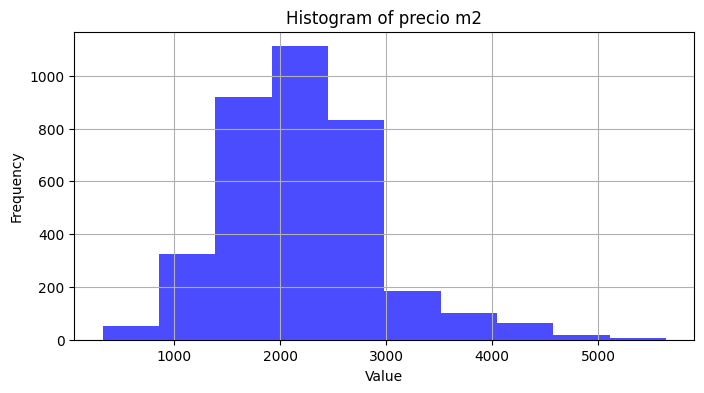

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df['PRECIO_M2'], bins=10, alpha=0.7, color='blue')
plt.title('Histogram of precio m2')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Visualizar correlaciones entre variables.

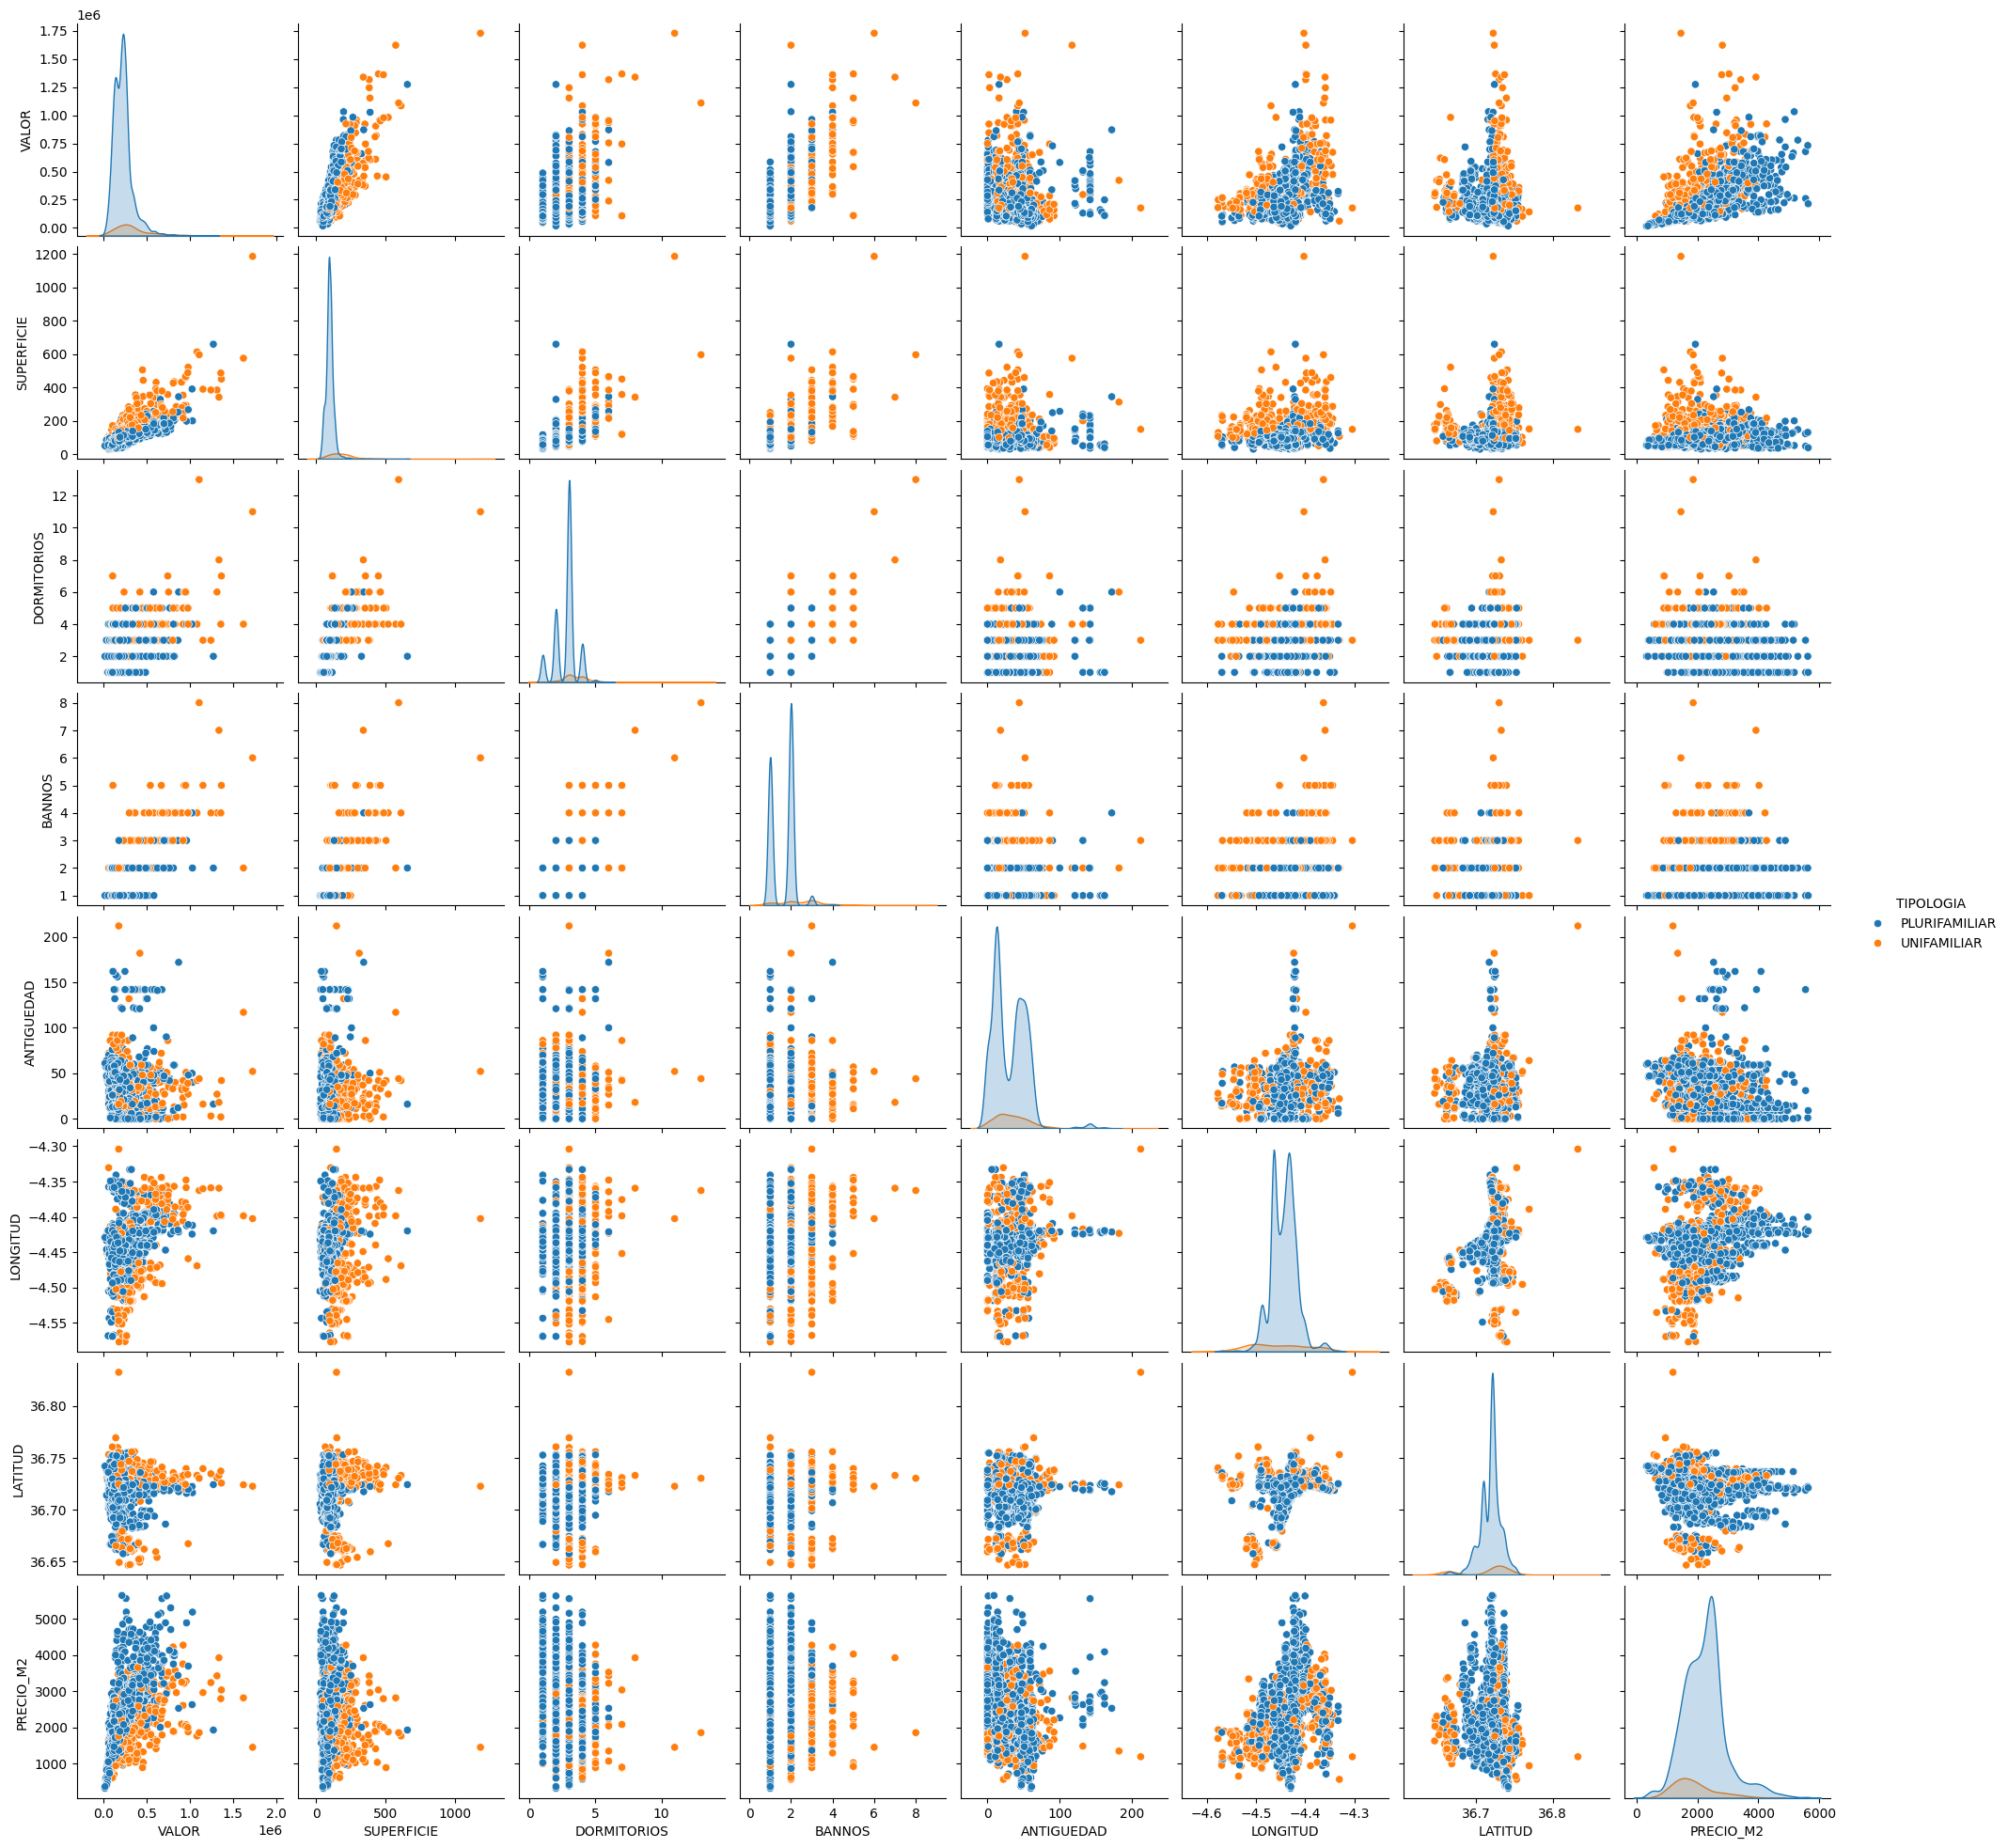

In [13]:
sns.pairplot(df[quantitative+['TIPOLOGIA']], hue="TIPOLOGIA")

En esta visualización podemos ver las correlaciones entre las distintas variables cuantitativas. 

/Users/juandecleene/Desktop/Real-State-Analysis-ML/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/juandecleene/Desktop/Real-State-Analysis-ML/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: >

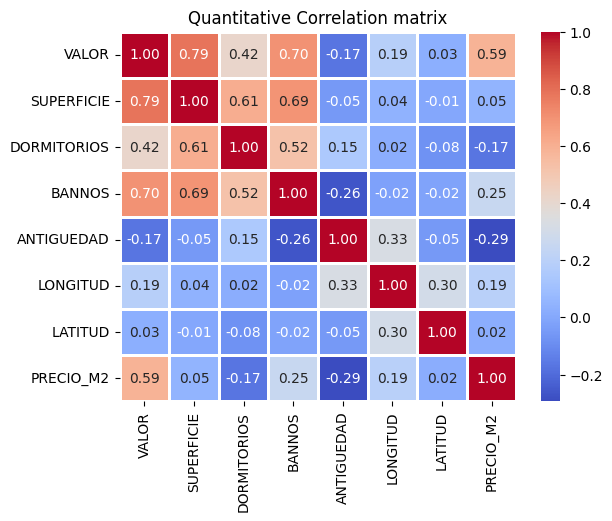

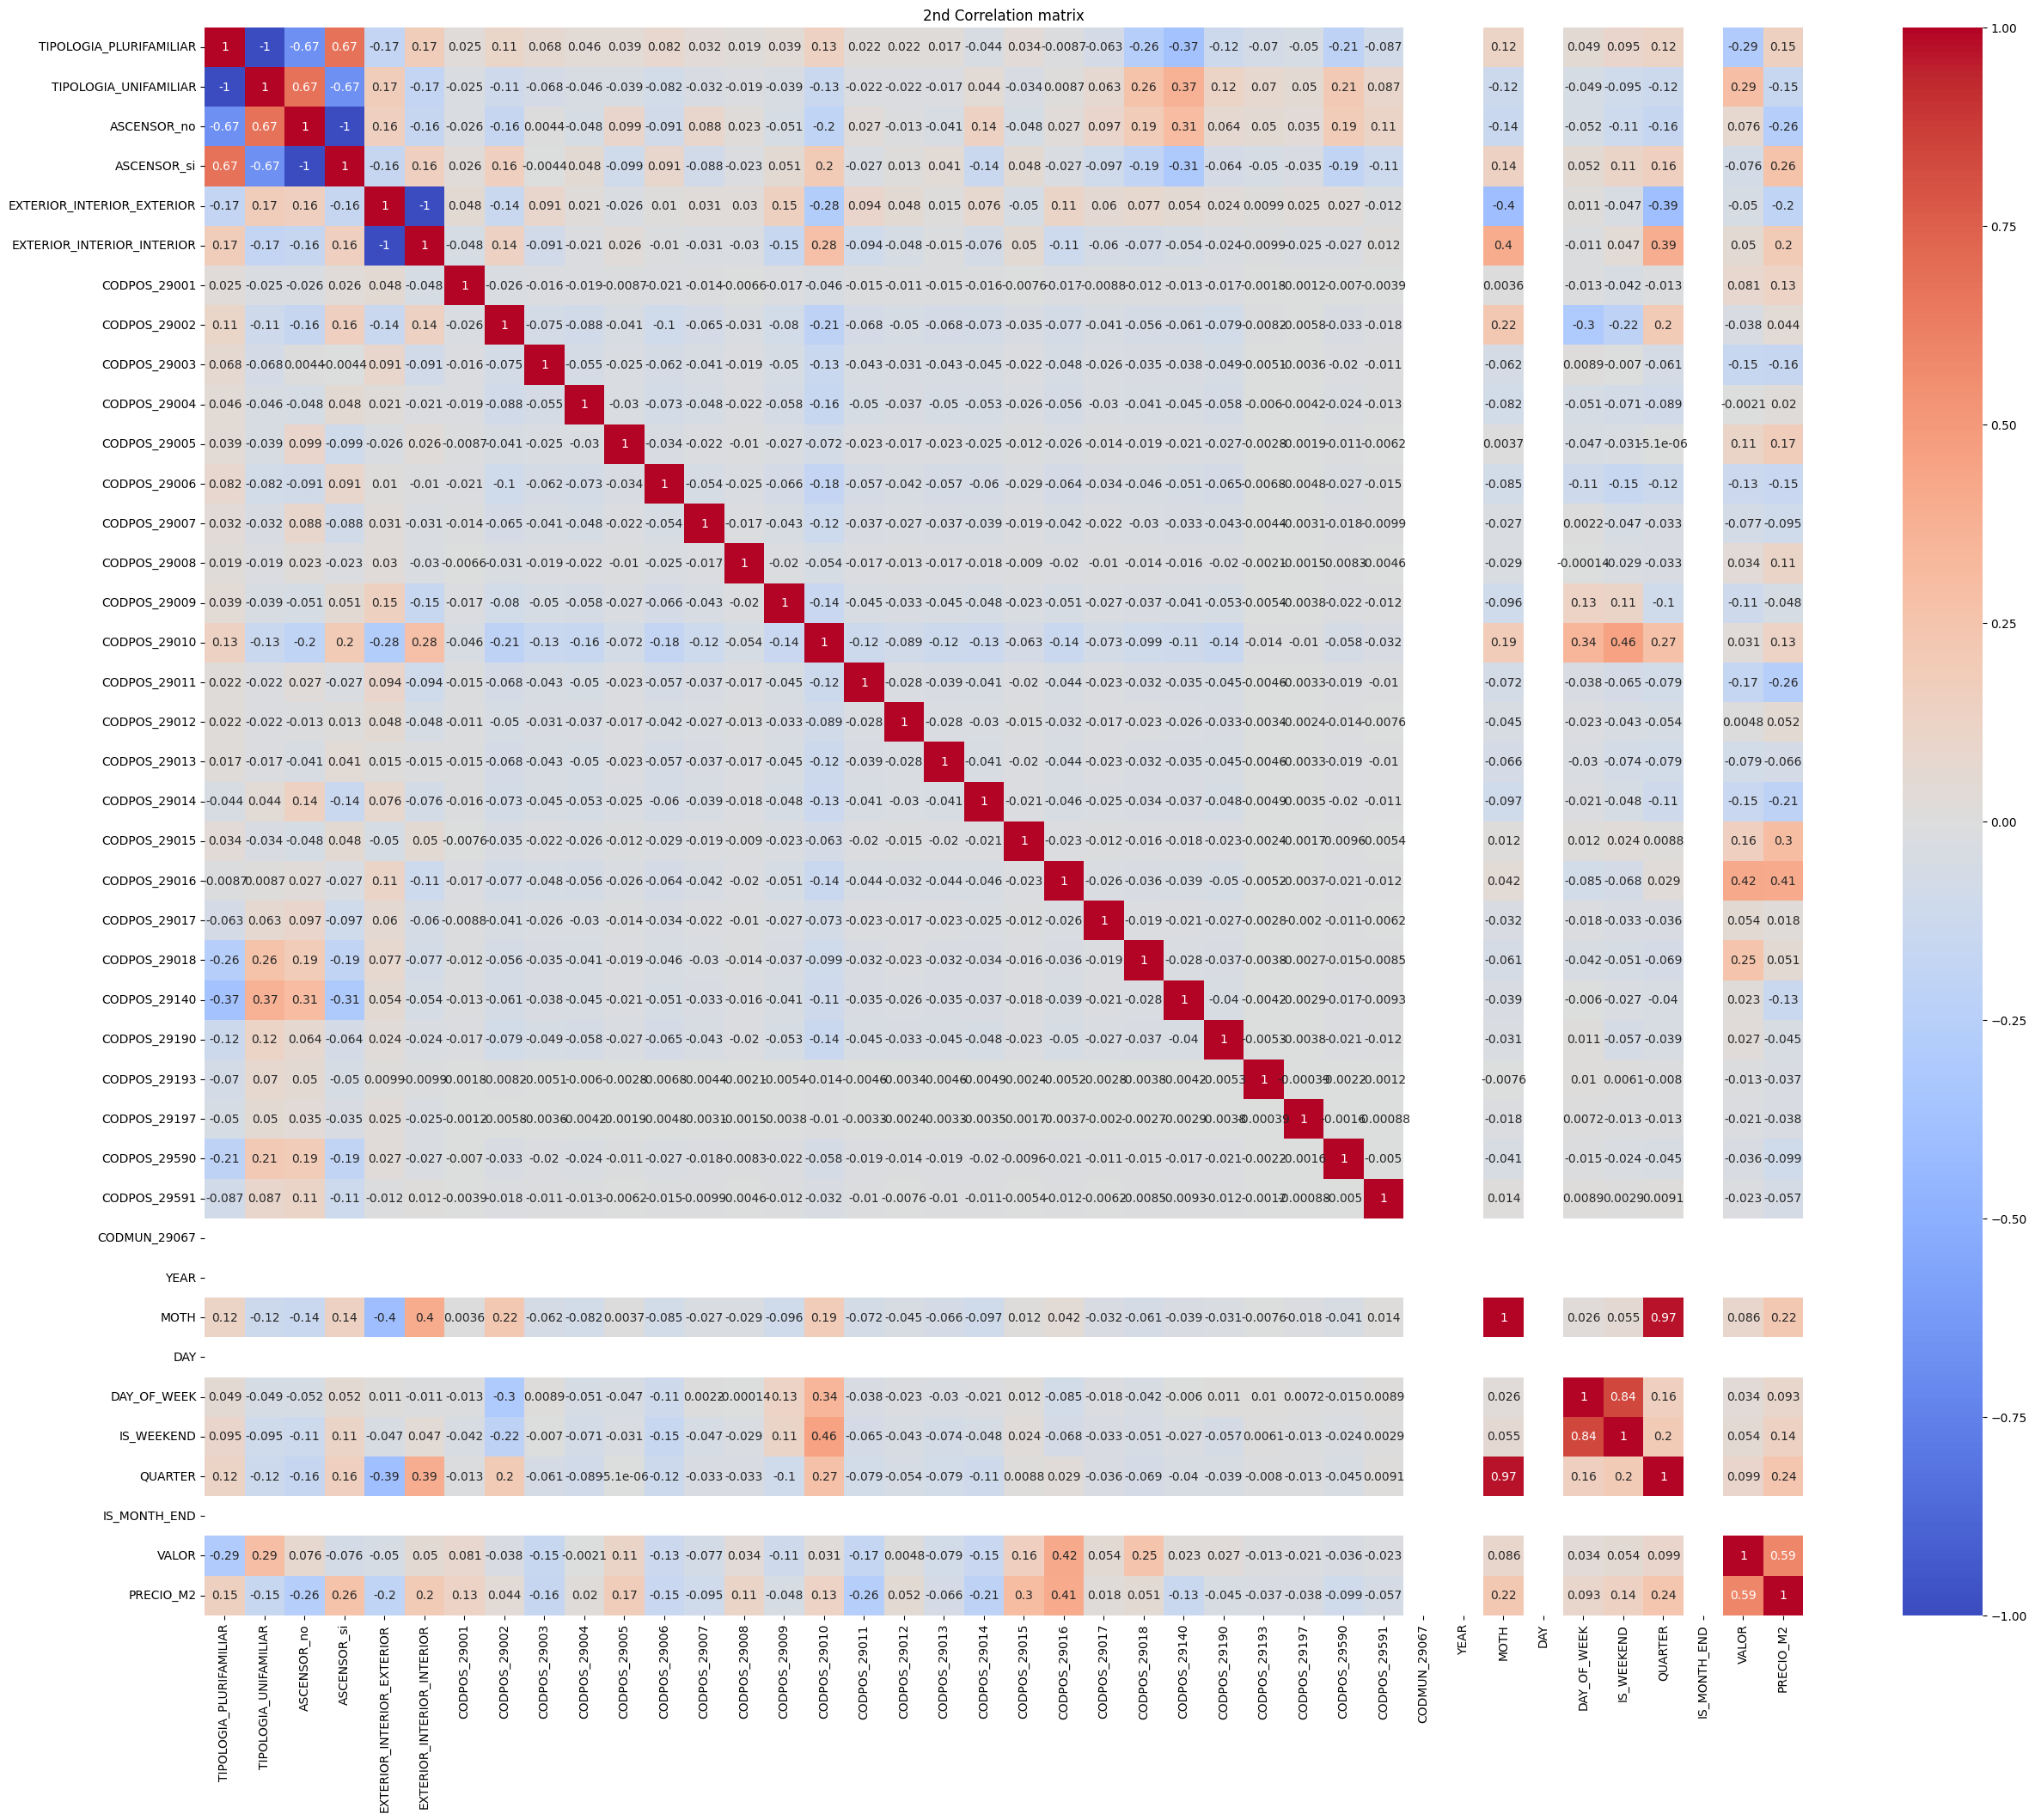

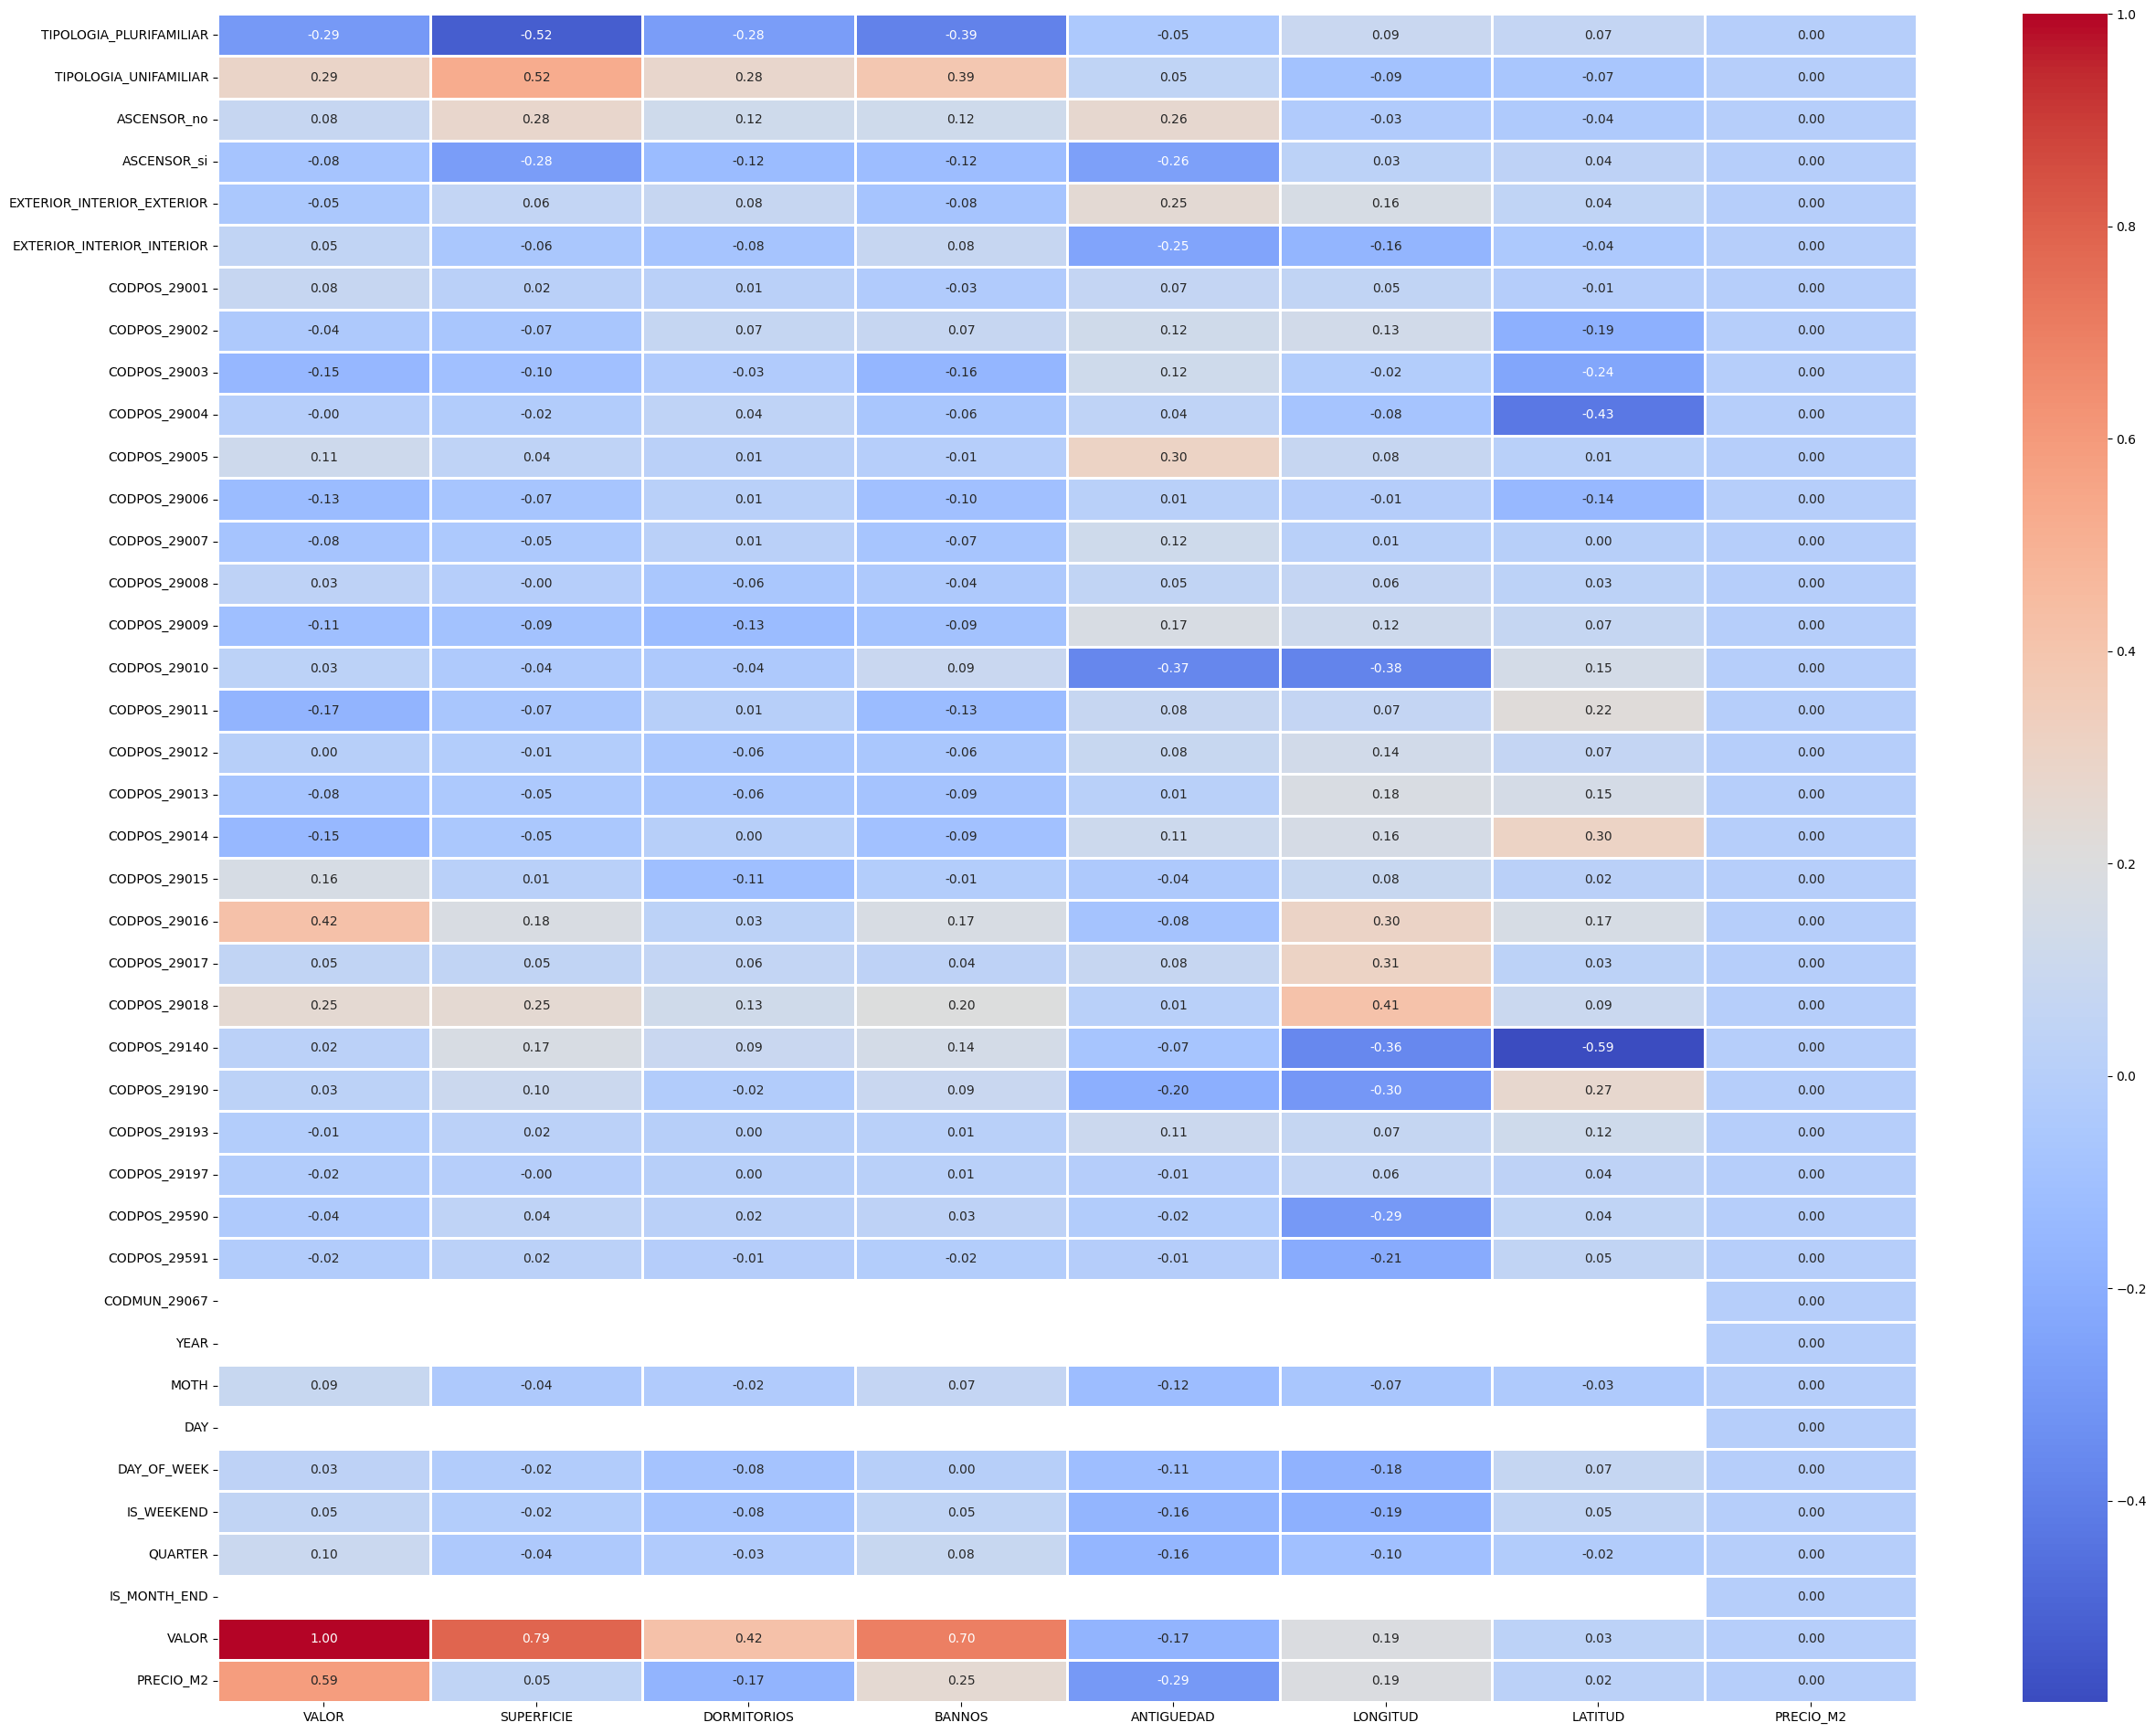

In [14]:
plt.figure(1)
corr = df[quantitative].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=2)
plt.title('Quantitative Correlation matrix')

plt.figure(2, figsize=(30, 24))
qualitative_encoded['VALOR'] = df['VALOR']
qualitative_encoded['PRECIO_M2'] = df['PRECIO_M2']
corr = qualitative_encoded.corr()
plt.title('2nd Correlation matrix')
sns.heatmap(corr, annot=True, cmap='coolwarm')
#SKIPEAR CÓDIGO POSTAL

plt.figure(3, figsize=(30, 24))
corr_dict = {}
for q1 in quantitative:
    corr_dict[q1] = {}
    for q2 in qualitative_encoded.columns:
        corr_dict[q1][q2] = df[q1].corr(qualitative_encoded[q2])
corr_dict['PRECIO_M2'] = {col: 0 for col in qualitative_encoded.columns}
corr = pd.DataFrame(corr_dict)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=2)
#SKIPEAR CÓDIGO POSTAL


<Axes: xlabel='LONGITUD', ylabel='LATITUD'>

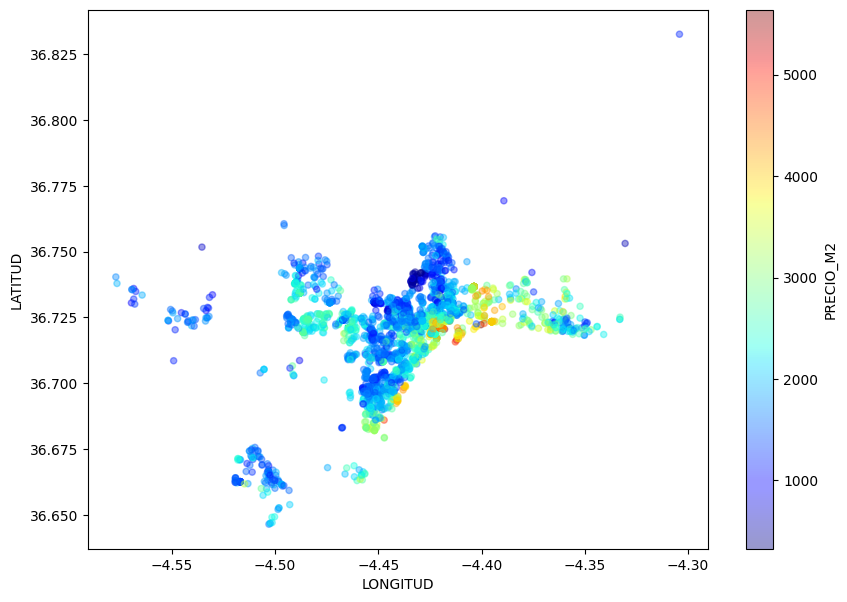

In [15]:

df.plot(kind="scatter", x="LONGITUD", y="LATITUD", alpha=0.4, figsize=(10,7),
    c="PRECIO_M2", cmap=plt.get_cmap("jet"), colorbar=True,
    sharex=False)
#HACERLO CON PLOTLY
#DESCRIBIR MEJOR

Cómo podemos observar, cerca la costa, el precio por metro cuadrado es mayor que en las afueras de **Málaga**.

**Predictions**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Engineering

In [17]:
#REGRESION LINEAL SIMPLE
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
#Probar más cosas

#STANDARIZA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

Multi linear regression

In [18]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred = linear_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print("Linear Regression")
print("------------------")
print('MSE: ', mse)
print('RMSE: ', rmse)
print('Intercept: ', linear_model.intercept_)
print('Coefficients: ', linear_model.coef_)

Linear Regression
------------------
MSE:  5.129846612182743e+33
RMSE:  7.1622947525096616e+16
Intercept:  -309944.60098990134
Coefficients:  [ 2.32608299e+17 -1.18657930e+17 -7.19125134e+16 ... -9.59373517e+14
  0.00000000e+00  0.00000000e+00]


In [19]:
# 2. Regresión Multivariable con Regularización Ridge
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Modelo Ridge con regularización
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calcular RMSPE
rmspe_ridge = calculate_rmspe(y_test, y_pred_ridge)
print("Ridge Regression")
print("------------------")
print('RMSPE: ', rmspe_ridge)
print('Intercept: ', ridge_model.intercept_)
print('Coefficients: ', ridge_model.coef_)

# Visualización de Residuos para Ridge
residuals_ridge = y_test - y_pred_ridge

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_ridge, alpha=0.7, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('Valores Reales vs Predichos (Ridge Regression)')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals_ridge, alpha=0.7, label='Residuos')
plt.axhline(0, color='red', linestyle='--', label='Cero')
plt.title('Residuos vs Valores Reales (Ridge Regression)')
plt.xlabel('Valores Reales')
plt.ylabel('Residuos')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'calculate_rmspe' is not defined

**Lasso Regression**

In [49]:

lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print("\nLasso")
print("------------------")
print('MSE: ', mse)
print('RMSE: ', rmse)
print('\nIntercept: ', lasso_model.intercept_)
print('Coefficients: ', lasso_model.coef_)


Lasso
------------------
MSE:  3659637396.6182976
RMSE:  60494.936950279545

Intercept:  72227123.21971288
Coefficients:  [ 1.52143528e+03 -4.35457219e+03  5.30944945e+04 -4.70612620e+02
  2.31262740e+05 -1.93925353e+06  4.69906220e+03 -2.41896399e-10
 -2.00701035e+04  4.58822341e-10 -8.37807323e+03  7.38008135e-10
  1.46271353e+05 -3.47120991e+04 -6.93228217e+04 -4.05697380e+04
  1.39436118e+05 -5.39880007e+04 -2.20078321e+04  7.04094189e+04
 -1.92405288e+04 -1.04706928e+04 -3.77628924e+04  3.56486097e+04
 -1.46076970e+04 -1.43007697e+04  1.97435974e+05  1.74844103e+05
  2.27952458e+04  6.52618715e+04 -1.67004500e+05 -1.86166760e+03
  4.07218563e+04 -1.41723709e+05 -4.90336561e+04 -5.68059888e+04
  0.00000000e+00  0.00000000e+00 -1.18106834e+03  0.00000000e+00
  5.97466039e+03 -6.79117711e+03  7.96347824e+03  0.00000000e+00]


/Users/juandecleene/Desktop/Real-State-Analysis-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.342e+10, tolerance: 5.612e+09
  model = cd_fast.enet_coordinate_descent(


Random Forest Hyperparameter Tuning Using Grid Search

In [ ]:
# Hyper parameter tuning
parameters = {
        'max_depth': [15],
        'n_estimators': [300, 500, 700, 1000],
}

grid_search = GridSearchCV(rf_model, parameters, cv=5, scoring='neg_root_mean_squared_error')   
grid_search.fit(X_train_scaled, y_train)
print("\nRandom Forest Grid Search")
print("------------------------------")
print('--> Best parameters: ', grid_search.best_params_)
print('--> Best RMSE ', grid_search.best_score_)

KeyboardInterrupt: 

Visualización de uno de los árboles de decisión de random forest

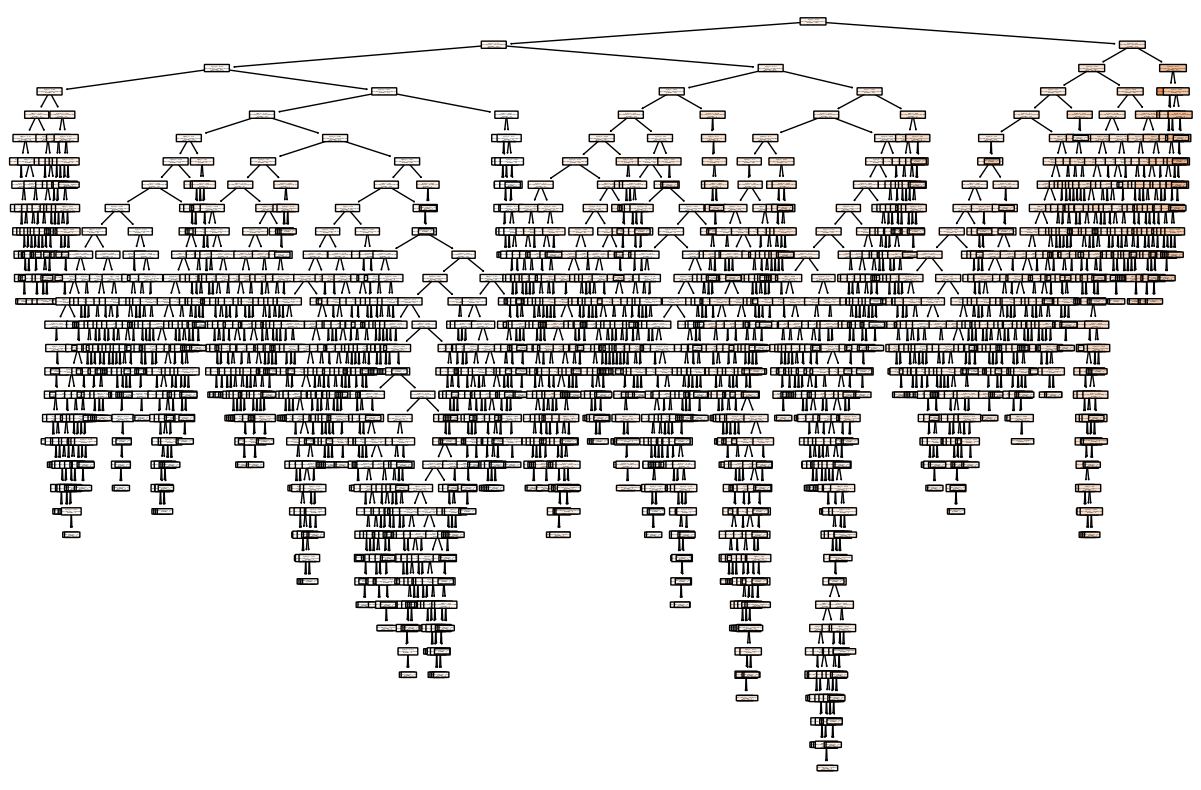

In [23]:
estimator = rf_model.estimators_[8]

plt.figure(figsize=(15, 10))
plot_tree(estimator, filled=True, rounded=True)
plt.show()

De este algoritmo, podemos extraer las variables que más influyen en la predicción final del modelo.

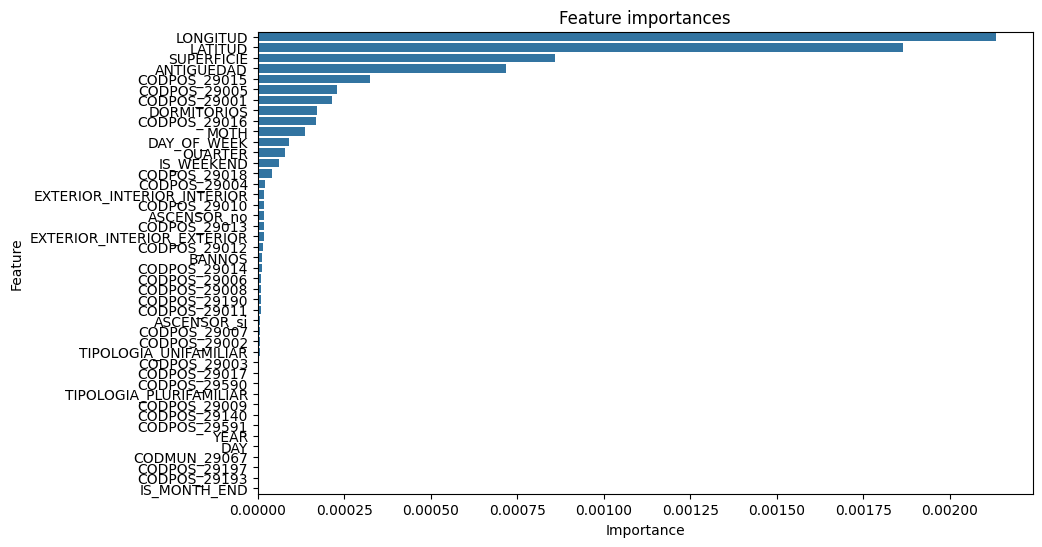

In [24]:
feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame(zip(X_train.columns, feature_importances), columns=['Feature', 'Importance'])
importance_df.set_index('Feature', inplace=True)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df['Importance'], y=importance_df.index)
plt.title('Feature importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#HACERLO CON PLOTLY
#SACAR CÓDIGOS POSTALES

La localización de la vivienda, junto con la superficie y la antiguedad, son las variables que más influyen en la predicción final.

In [25]:
results = grid_search.cv_results_
params = results['params']
mean_test_scores = results['mean_test_score']
std_test_scores = results['std_test_score']

print("\nRandom Forest Grid Search Results")
print("-------------------------------------")
for param, mean_score, std_score in zip(params, mean_test_scores, std_test_scores):
    print(f"Parameters: {param}, Mean RMSE: {-mean_score}, Std RMSE: {std_score}")



Random Forest Grid Search Results
-------------------------------------
Parameters: {'max_depth': 15, 'n_estimators': 300}, Mean RMSE: 50947.89596012891, Std RMSE: 4774.761809248033
Parameters: {'max_depth': 15, 'n_estimators': 500}, Mean RMSE: 50749.26045514025, Std RMSE: 4678.331238826873
Parameters: {'max_depth': 15, 'n_estimators': 700}, Mean RMSE: 50766.19406642559, Std RMSE: 4726.087209227244
Parameters: {'max_depth': 15, 'n_estimators': 1000}, Mean RMSE: 50789.70723922392, Std RMSE: 4826.084772309172


Podemos observar que los mejores parámetros para random forest son los siguientes:

**max_depth: 15, n_estimators: 500** (RMSE: 50749.26045514025)

Evidentemente el RMSE es muy alto, por lo que se puede concluir que el modelo no es muy bueno, sobre todo para predecir precios bajos. Habría que adaptar el modelo a los datos.

In [26]:
def calculate_rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100

XGBoost

RMSPE XGBoost: 16.32%


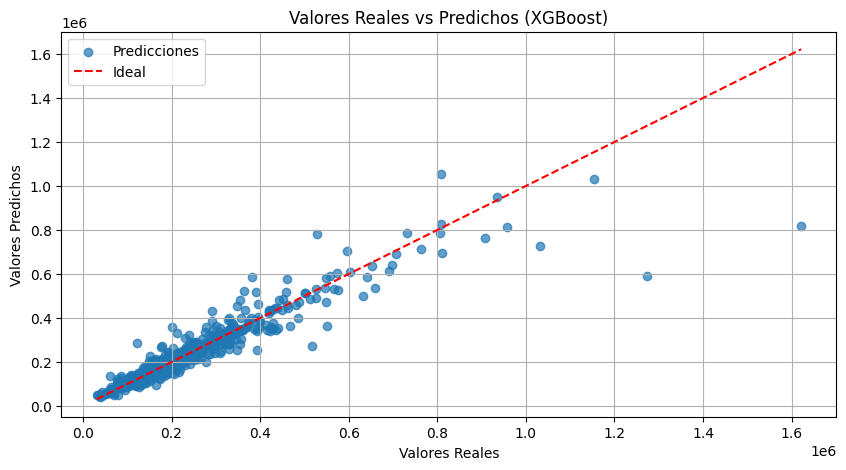

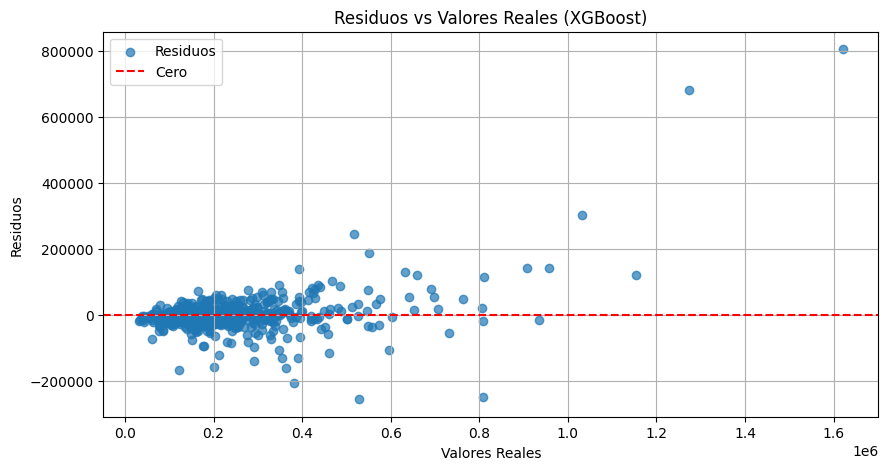

In [29]:
#1. Entrenamiento y Evaluación del Modelo XGBoost
# Crear y entrenar el modelo
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)

rmspe_xgb = calculate_rmspe(y_test, y_pred_xgb)
print(f"RMSPE XGBoost: {rmspe_xgb:.2f}%")

#Visualización de Residuos con Matplotlib y Seaborn
residuals_xgb = y_test - y_pred_xgb

# Valores reales vs predichos
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_xgb, alpha=0.7, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('Valores Reales vs Predichos (XGBoost)')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.legend()
plt.grid(True)
plt.show()

# Residuos vs valores reales
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals_xgb, alpha=0.7, label='Residuos')
plt.axhline(0, color='red', linestyle='--', label='Cero')
plt.title('Residuos vs Valores Reales (XGBoost)')
plt.xlabel('Valores Reales')
plt.ylabel('Residuos')
plt.legend()
plt.grid(True)
plt.show()


*El XGBoost base no está mal, con un RMSPE del 16.32%*

RMSPE Random Forest: 17.84%


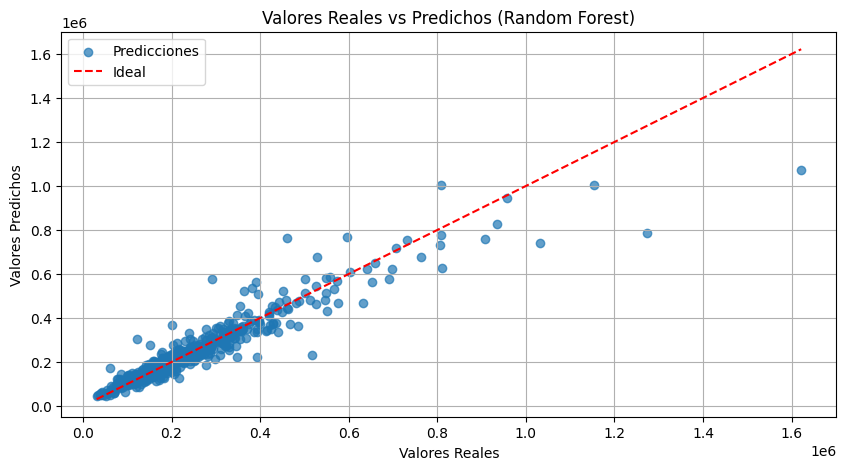

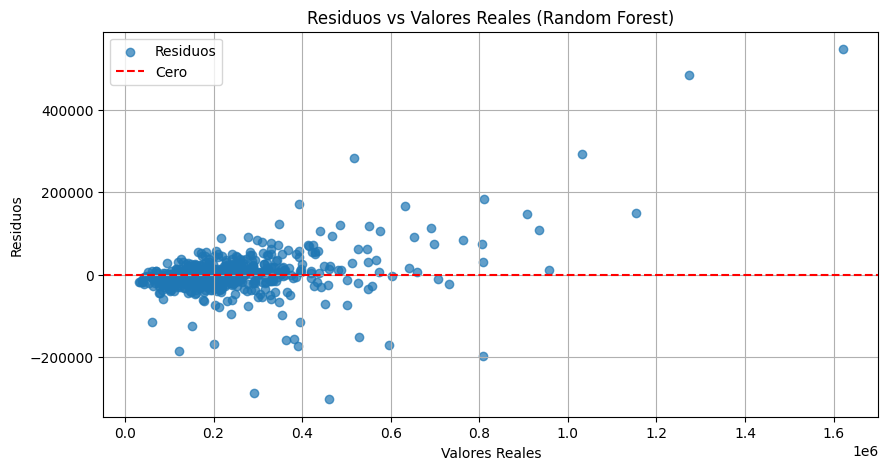

In [ ]:
# 2. Entrenamiento y Evaluación del Modelo Random Forest
# Crear y entrenar el modelo mejorado
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Calcular RMSPE
rmspe_rf = calculate_rmspe(y_test, y_pred_rf)
print(f"RMSPE Random Forest: {rmspe_rf:.2f}%")

# 5. Visualización de Residuos para Random Forest
residuals_rf = y_test - y_pred_rf

# Valores reales vs predichos
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.7, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('Valores Reales vs Predichos (Random Forest)')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.legend()
plt.grid(True)
plt.show()

# Residuos vs valores reales
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals_rf, alpha=0.7, label='Residuos')
plt.axhline(0, color='red', linestyle='--', label='Cero')
plt.title('Residuos vs Valores Reales (Random Forest)')
plt.xlabel('Valores Reales')
plt.ylabel('Residuos')
plt.legend()
plt.grid(True)
plt.show()



Con el nuevo modelo se puede especular que el modelo de Random Forest no es del todo malo pero menos preciso que el XGBoost ya que tiene menos cuadrado medio de error.


Random Forest Randomized Search
--------------------------------
--> Best parameters:  {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
RMSPE Random Forest: 18.10%


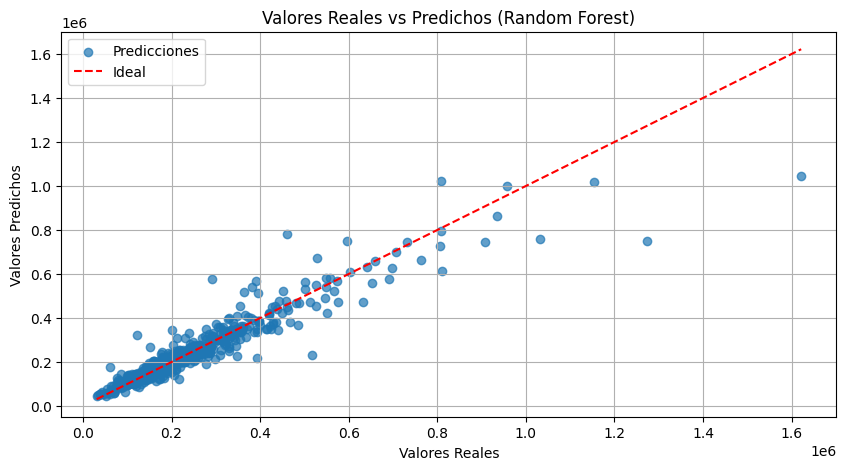

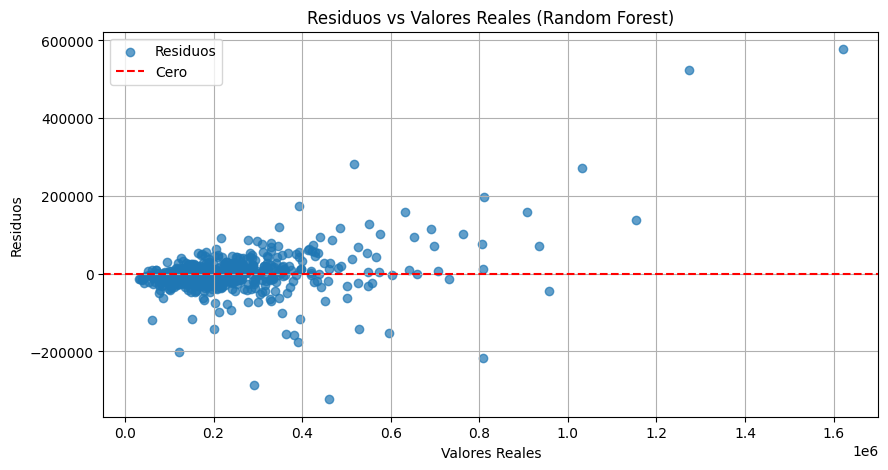

In [59]:
# 3. Random Forest con RandomizedSearchCV
rf_model = RandomForestRegressor(random_state=42)
parameters = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

randomized_search = RandomizedSearchCV(
    rf_model, parameters, n_iter=10, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42
)
randomized_search.fit(X_train, y_train)

# Obtener los mejores parámetros y modelo ajustado
best_rf_model = randomized_search.best_estimator_
print("\nRandom Forest Randomized Search")
print("--------------------------------")
print('--> Best parameters: ', randomized_search.best_params_)

# Predicciones
y_pred_rf = best_rf_model.predict(X_test)

# Calcular RMSPE
rmspe_rf = calculate_rmspe(y_test, y_pred_rf)
print(f"RMSPE Random Forest: {rmspe_rf:.2f}%")

# Visualización de Residuos para Random Forest
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.7, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('Valores Reales vs Predichos (Random Forest)')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals_rf, alpha=0.7, label='Residuos')
plt.axhline(0, color='red', linestyle='--', label='Cero')
plt.title('Residuos vs Valores Reales (Random Forest)')
plt.xlabel('Valores Reales')
plt.ylabel('Residuos')
plt.legend()
plt.grid(True)
plt.show()

# Este código incluye Ridge Regression con regularización para la regresión multivariable,
# optimiza Random Forest con RandomizedSearchCV y añade visualizaciones de residuos para ambos modelos.


**Winner Model XGBoost**


XGBoost Randomized Search
--------------------------------
--> Best parameters:  {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Modelo guardado como 'best_xgb_model.pkl'
RMSPE XGBoost (log transformado): 14.56%


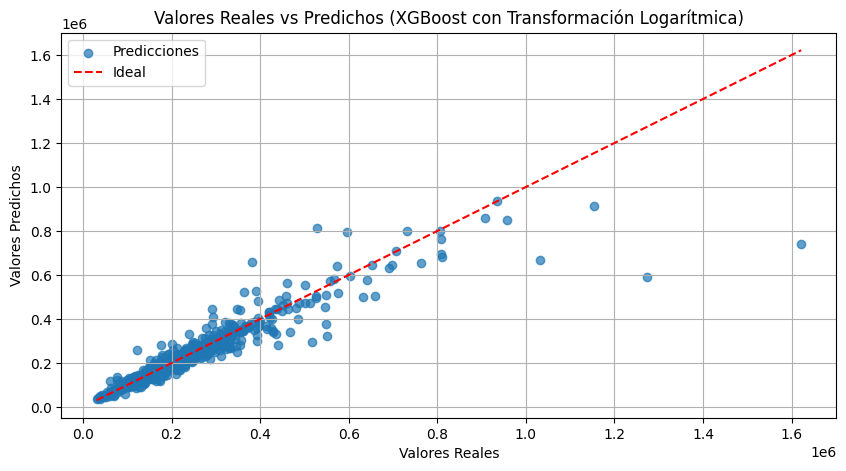

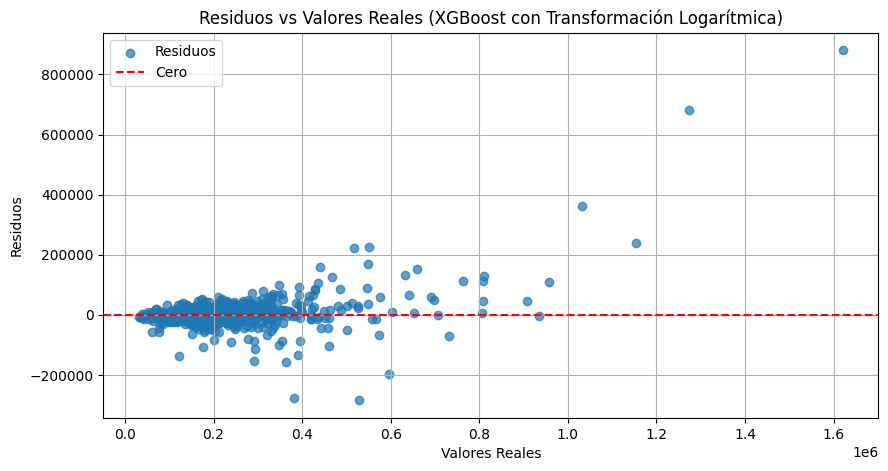


Importancia de las características
                       Feature  Importance
2                       BANNOS    0.385534
0                   SUPERFICIE    0.082488
22                CODPOS_29011    0.063827
27                CODPOS_29016    0.052308
8                  ASCENSOR_no    0.043910
9                  ASCENSOR_si    0.039400
26                CODPOS_29015    0.034604
4                     LONGITUD    0.022110
6      TIPOLOGIA_PLURIFAMILIAR    0.019694
16                CODPOS_29005    0.019159
1                  DORMITORIOS    0.018442
3                   ANTIGUEDAD    0.017321
30                CODPOS_29140    0.016011
34                CODPOS_29590    0.015513
5                      LATITUD    0.015238
15                CODPOS_29004    0.012094
19                CODPOS_29008    0.011887
25                CODPOS_29014    0.011726
12                CODPOS_29001    0.011278
41                  IS_WEEKEND    0.010209
24                CODPOS_29013    0.010151
13                

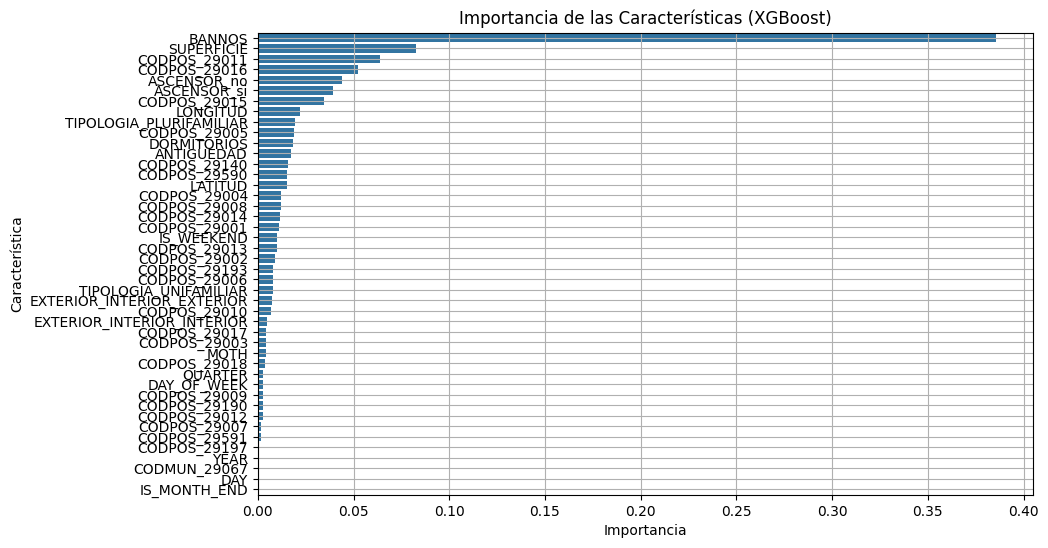

In [ ]:
# 4. Optimización y Evaluación del Modelo XGBoost con Transformación Logarítmica
# Transformación logarítmica del target
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Crear y entrenar el modelo con hiperparámetros iniciales
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=6, learning_rate=0.1)

# Parámetros para RandomizedSearchCV
parameters_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

randomized_search_xgb = RandomizedSearchCV(
    xgb_model, parameters_xgb, n_iter=15, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42
)
randomized_search_xgb.fit(X_train, y_train_log)

# Obtener los mejores parámetros y modelo ajustado
best_xgb_model = randomized_search_xgb.best_estimator_
print("\nXGBoost Randomized Search")
print("--------------------------------")
print('--> Best parameters: ', randomized_search_xgb.best_params_)

# Guardar el modelo optimizado
joblib.dump(best_xgb_model, 'best_xgb_model.pkl')
print("Modelo guardado como 'best_xgb_model.pkl'")

# Predicciones (invirtiendo la transformación logarítmica)
y_pred_xgb_log = best_xgb_model.predict(X_test)
y_pred_xgb = np.exp(y_pred_xgb_log)

# Calcular RMSPE
rmspe_xgb = calculate_rmspe(y_test, y_pred_xgb)
print(f"RMSPE XGBoost (log transformado): {rmspe_xgb:.2f}%")

# Visualización de Residuos para XGBoost
residuals_xgb = y_test - y_pred_xgb

plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_xgb, alpha=0.7, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('Valores Reales vs Predichos (XGBoost con Transformación Logarítmica)')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals_xgb, alpha=0.7, label='Residuos')
plt.axhline(0, color='red', linestyle='--', label='Cero')
plt.title('Residuos vs Valores Reales (XGBoost con Transformación Logarítmica)')
plt.xlabel('Valores Reales')
plt.ylabel('Residuos')
plt.legend()
plt.grid(True)
plt.show()

# Importancia de las características
feature_importances = best_xgb_model.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(len(feature_importances))]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\nImportancia de las características")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title('Importancia de las Características (XGBoost)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(True)
plt.show()

# Este código optimiza y evalúa el modelo XGBoost usando RandomizedSearchCV,
# aplica una transformación logarítmica al target, guarda el modelo, y visualiza los residuos y la importancia de las características.


*Por ahora, estos parámetros son los que generan menos RMSE. Este modelo es el elegido de momento.*

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Definir el modelo con regularización
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1)  # Salida para regresión
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['RootMeanSquaredError'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(
    X_train_scaled, np.log(y_train),
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluar el modelo
loss, rmse = model.evaluate(X_test_scaled, np.log(y_test))
print(f"RMSE (log scale): {rmse:.2f}")

# Predicciones (invirtiendo la transformación logarítmica)
y_pred_nn_log = model.predict(X_test_scaled).flatten()
y_pred_nn = np.exp(y_pred_nn_log)

# Calcular RMSPE
rmspe_nn = calculate_rmspe(y_test, y_pred_nn)
print(f"RMSPE TensorFlow/Keras: {rmspe_nn:.2f}%")


Epoch 1/100


/Users/juandecleene/Desktop/Real-State-Analysis-ML/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 11.1256 - loss: 124.8853 - val_RootMeanSquaredError: 4.5862 - val_loss: 21.1398
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 4.0758 - loss: 16.8336 - val_RootMeanSquaredError: 2.1355 - val_loss: 4.6727
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 3.1555 - loss: 10.0741 - val_RootMeanSquaredError: 1.8531 - val_loss: 3.5467
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 2.9802 - loss: 8.9975 - val_RootMeanSquaredError: 1.6828 - val_loss: 2.9450
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 2.8466 - loss: 8.2238 - val_RootMeanSquaredError: 1.7033 - val_loss: 3.0134
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 2.8546 - loss: 8.2635 - val_RootMeanSquaredError: 1.5743 - val_loss: 2.5912
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 2.9663 - loss: 8.9418 - v

*No tiene sentido porque el RMPSE es muy alto*